<a href="https://colab.research.google.com/github/Naveenithi/EcoType-Forest-Cover-Type-Prediction-Using-Machine-Learning/blob/main/EcoType_Forest_Cover_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Data Collection

Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np

# Visualization (we'll use later)
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cover_type (1).csv to cover_type (1).csv


In [ ]:
df = pd.read_csv('cover_type (1).csv')

Basic Dataset Exploration

In [ ]:
# First 5 rows
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


In [ ]:
# Shape of dataset
df.shape

(145890, 13)

In [ ]:
# Column names
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [ ]:
# Data types and nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145890 entries, 0 to 145889
Data columns (total 13 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   Elevation                           145890 non-null  int64 
 1   Aspect                              145890 non-null  int64 
 2   Slope                               145890 non-null  int64 
 3   Horizontal_Distance_To_Hydrology    145890 non-null  int64 
 4   Vertical_Distance_To_Hydrology      145890 non-null  int64 
 5   Horizontal_Distance_To_Roadways     145890 non-null  int64 
 6   Hillshade_9am                       145890 non-null  int64 
 7   Hillshade_Noon                      145890 non-null  int64 
 8   Hillshade_3pm                       145890 non-null  int64 
 9   Horizontal_Distance_To_Fire_Points  145890 non-null  int64 
 10  Cover_Type                          145890 non-null  object
 11  Wilderness_Area                     145

In [ ]:
# Statistical summary
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area,Soil_Type
count,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000,145890.000000
mean,2874.458949,141.127418,11.925574,251.824738,34.554322,3313.827541,217.368106,224.874748,139.788203,3044.958105,1.186593,23.364905
std,210.801279,107.719296,6.319326,192.473899,41.215776,1687.779953,21.590298,16.084851,31.311690,1761.882341,0.656571,8.215184
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,1.000000,1.000000
25%,2747.000000,54.000000,7.000000,95.000000,7.000000,1848.000000,207.000000,216.000000,121.000000,1608.000000,1.000000,12.000000
50%,2909.000000,108.000000,11.000000,212.000000,23.000000,3420.000000,222.000000,226.000000,140.000000,2713.000000,1.000000,29.000000
75%,3004.000000,217.000000,15.000000,362.000000,51.000000,4673.000000,232.000000,236.000000,159.000000,4478.000000,1.000000,29.000000
max,3849.000000,360.000000,61.000000,1343.000000,554.000000,7117.000000,254.000000,254.000000,248.000000,7173.000000,4.000000,40.000000


Check Target Variable

In [ ]:
df['Cover_Type'].value_counts()

,count
Cover_Type,
Lodgepole Pine,103071
Spruce/Fir,31110
Aspen,3069
Krummholz,2160
Ponderosa Pine,2160
Douglas-fir,2160
Cottonwood/Willow,2160


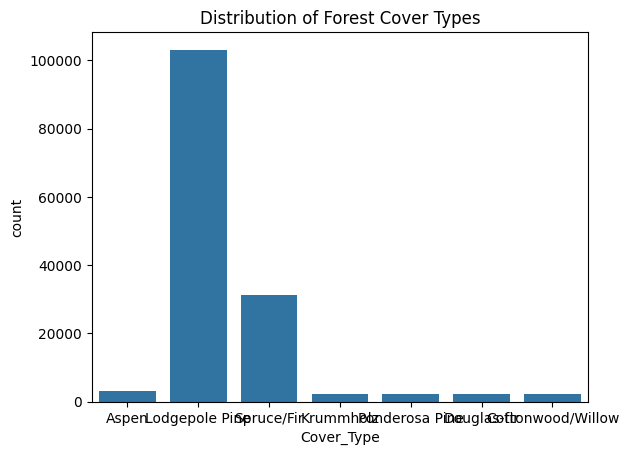

In [ ]:
sns.countplot(x='Cover_Type', data=df)
plt.title("Distribution of Forest Cover Types")
plt.show()

Check Missing Values

In [ ]:
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


# Expected Understanding
*   Dataset contains 145,891 rows and 13 features
*   Target variable: Cover_Type (7 classes)
*   Features include:
*   Terrain: Elevation, Slope, Aspect
*   Distance-based: Hydrology, Roadways, Fire Points
*   Light conditions: Hillshade values
*   Categorical: Wilderness_Area, Soil_Type
*   No/low missing values (verify from output)
*   Multi-class classification problem













# Step 2: Data Understanding

Dataset Overview

In [ ]:
df['Cover_Type'].value_counts(normalize=True) * 100

,proportion
Cover_Type,
Lodgepole Pine,70.649805
Spruce/Fir,21.324285
Aspen,2.103640
Krummholz,1.480568
Ponderosa Pine,1.480568
Douglas-fir,1.480568
Cottonwood/Willow,1.480568


Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

Unique Values in Categorical Columns

In [ ]:
df['Wilderness_Area'].value_counts()

,count
Wilderness_Area,
1,134367
3,6349
4,4675
2,499


In [ ]:
df['Soil_Type'].value_counts()

,count
Soil_Type,
29,60696
12,29144
30,18158
23,10150
20,6098
16,2219
24,2169
10,2142
18,1829


# Step 3: Data Cleaning & Transformation

1. Skip Missing Value Handling

In [ ]:
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


2. Handle Outliers

In [ ]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

if 'Cover_Type' in num_cols:
    num_cols = num_cols.drop('Cover_Type')

In [ ]:
print("Columns:\n", df.columns)
print("\nNumeric Columns:\n", num_cols)

Columns:
 Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type'],
      dtype='object')

Numeric Columns:
 Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type'],
      dtype='object')


In [ ]:
def handle_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] < lower, lower, df[col])
        df[col] = np.where(df[col] > upper, upper, df[col])
    return df

In [ ]:
df = handle_outliers_iqr(df, num_cols)

3. Handle Skewness

In [ ]:
skewness = df[num_cols].skew().sort_values(ascending=False)
skewness

,0
Vertical_Distance_To_Hydrology,0.861265
Horizontal_Distance_To_Hydrology,0.792349
Aspect,0.689432
Slope,0.621361
Horizontal_Distance_To_Fire_Points,0.365249
Wilderness_Area,0.000000
Hillshade_3pm,-0.001189
Horizontal_Distance_To_Roadways,-0.058240
Elevation,-0.340370
Hillshade_Noon,-0.505363


In [ ]:
skewed_cols = skewness[skewness > 0.75].index

In [ ]:
for col in skewed_cols:
    df[col] = np.log1p(df[col])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df[['Wilderness_Area', 'Soil_Type']].head()

,Wilderness_Area,Soil_Type
0,1.0,29.0
1,1.0,29.0
2,1.0,12.0
3,1.0,30.0
4,1.0,29.0


# Step 4: Feature Engineering

Distance Ratios

In [ ]:
df['Hydrology_Ratio'] = df['Horizontal_Distance_To_Hydrology'] / (df['Vertical_Distance_To_Hydrology'] + 1)

In [ ]:
df['Road_Fire_Ratio'] = df['Horizontal_Distance_To_Roadways'] / (df['Horizontal_Distance_To_Fire_Points'] + 1)

Hillshade Differences

In [ ]:
df['Hillshade_Diff_1'] = df['Hillshade_9am'] - df['Hillshade_Noon']

In [ ]:
df['Hillshade_Diff_2'] = df['Hillshade_Noon'] - df['Hillshade_3pm']

Elevation-Based Feature

In [ ]:
df['Elevation_Slope'] = df['Elevation'] * df['Slope']

# 3. Encoding Categorical Variables

In [ ]:
df[['Wilderness_Area', 'Soil_Type']].head()

,Wilderness_Area,Soil_Type
0,1.0,29.0
1,1.0,29.0
2,1.0,12.0
3,1.0,30.0
4,1.0,29.0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le_wild = LabelEncoder()
le_soil = LabelEncoder()

df['Wilderness_Area'] = le_wild.fit_transform(df['Wilderness_Area'])
df['Soil_Type'] = le_soil.fit_transform(df['Soil_Type'])

# 4. Save Encoders

In [ ]:
import joblib

joblib.dump(le_wild, 'wilderness_encoder.pkl')
joblib.dump(le_soil, 'soil_encoder.pkl')

['soil_encoder.pkl']

During Inference (Later Use)

In [ ]:
le_wild = joblib.load('wilderness_encoder.pkl')
le_soil = joblib.load('soil_encoder.pkl')

In [ ]:
joblib.dump(df.columns, 'model_columns.pkl')

['model_columns.pkl']

# 5. Final Feature Check

In [ ]:
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Hydrology_Ratio,Road_Fire_Ratio,Hillshade_Diff_1,Hillshade_Diff_2,Elevation_Slope
0,2596.0,51.0,3.0,5.556828,0.000000,510.0,221.0,232.0,148.0,6279.0,Aspen,0,27,5.556828,0.081210,-11.0,84.0,7788.0
1,2590.0,56.0,2.0,5.361292,NaN,390.0,220.0,235.0,151.0,6225.0,Aspen,0,27,NaN,0.062641,-15.0,84.0,5180.0
2,2804.0,139.0,9.0,5.594711,4.189655,3180.0,234.0,238.0,135.0,6121.0,Lodgepole Pine,0,11,1.078051,0.519438,-4.0,103.0,25236.0
3,2785.0,155.0,18.0,5.493061,4.770685,3090.0,238.0,238.0,122.0,6211.0,Lodgepole Pine,0,28,0.951891,0.497424,0.0,116.0,50130.0
4,2595.0,45.0,2.0,5.036953,-inf,391.0,220.0,234.0,150.0,6172.0,Aspen,0,27,-0.000000,0.063340,-14.0,84.0,5190.0


In [ ]:
df.shape

(145890, 18)

1. Replace Inf values

In [ ]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)

2. Handle Newly Created Missing Values

In [ ]:
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,12221
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_13853/1384138331.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


3. Safer Feature Engineering

In [ ]:
df['Hydrology_Ratio'] = df['Horizontal_Distance_To_Hydrology'] / (abs(df['Vertical_Distance_To_Hydrology']) + 1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
df['Cover_Type'] = target_encoder.fit_transform(df['Cover_Type'])

Save Target Encoder

In [ ]:
import joblib
joblib.dump(target_encoder, 'target_encoder.pkl')

['target_encoder.pkl']

In [ ]:
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


Save again

In [ ]:
import joblib

joblib.dump(le_wild, 'wilderness_encoder.pkl')
joblib.dump(le_soil, 'soil_encoder.pkl')
joblib.dump(target_encoder, 'target_encoder.pkl')

['target_encoder.pkl']

Save columns

In [ ]:
joblib.dump(df.columns, 'model_columns.pkl')

['model_columns.pkl']

In [ ]:
df.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Cover_Type', 'Wilderness_Area',
       'Soil_Type', 'Hydrology_Ratio', 'Road_Fire_Ratio', 'Hillshade_Diff_1',
       'Hillshade_Diff_2', 'Elevation_Slope'],
      dtype='object')

# Step 5: Exploratory Data Analysis (EDA)

1. Univariate Analysis (Single Feature)

Distribution of Numerical Features (Histograms)

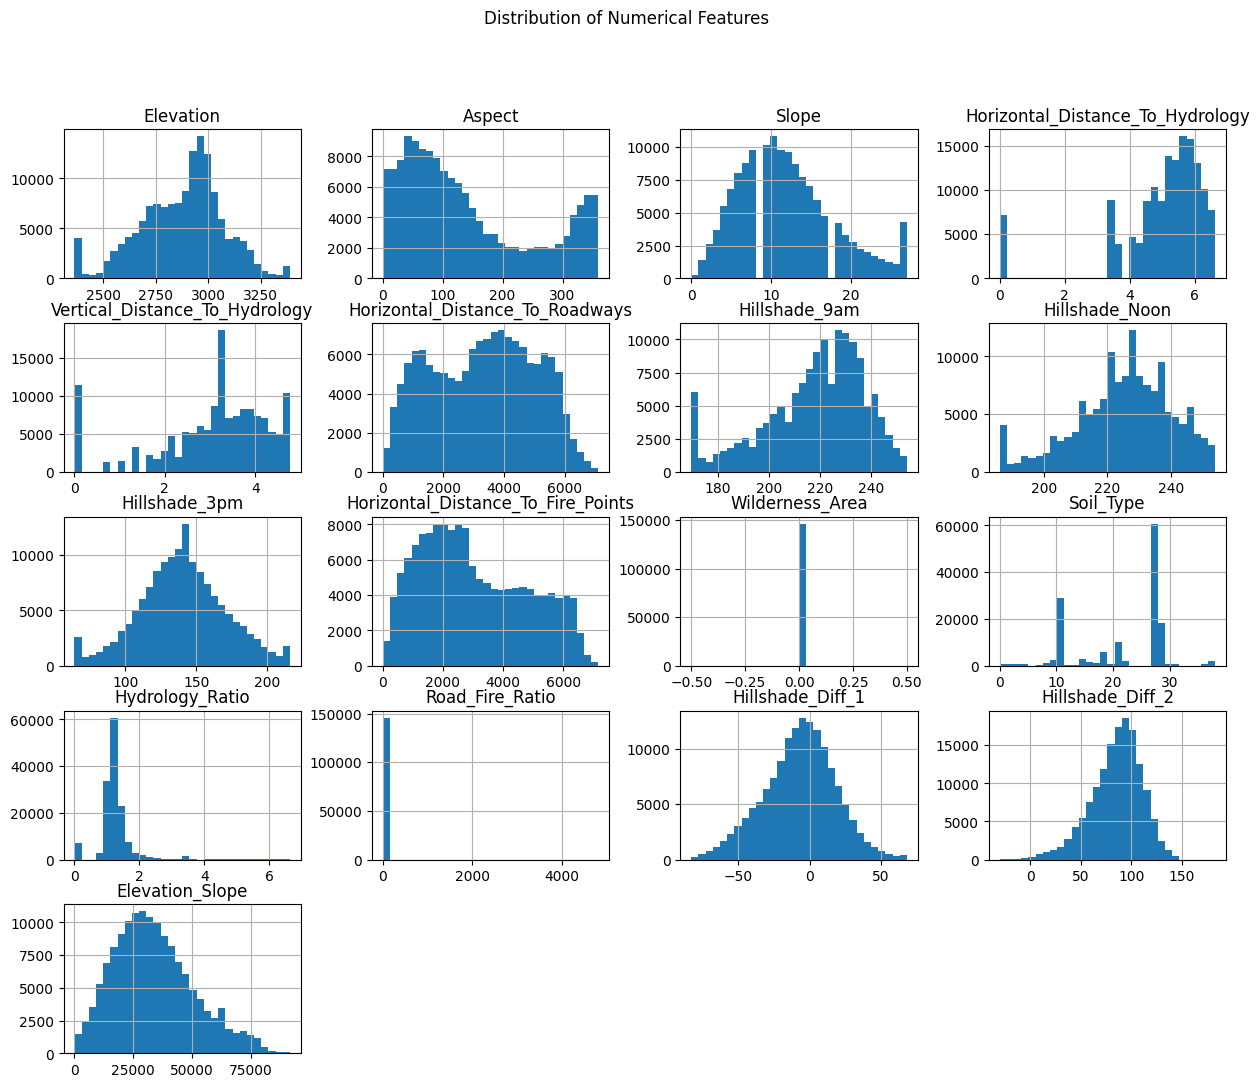

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop('Cover_Type')

df[num_cols].hist(figsize=(15,12), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

Boxplots (Outlier Visualization)

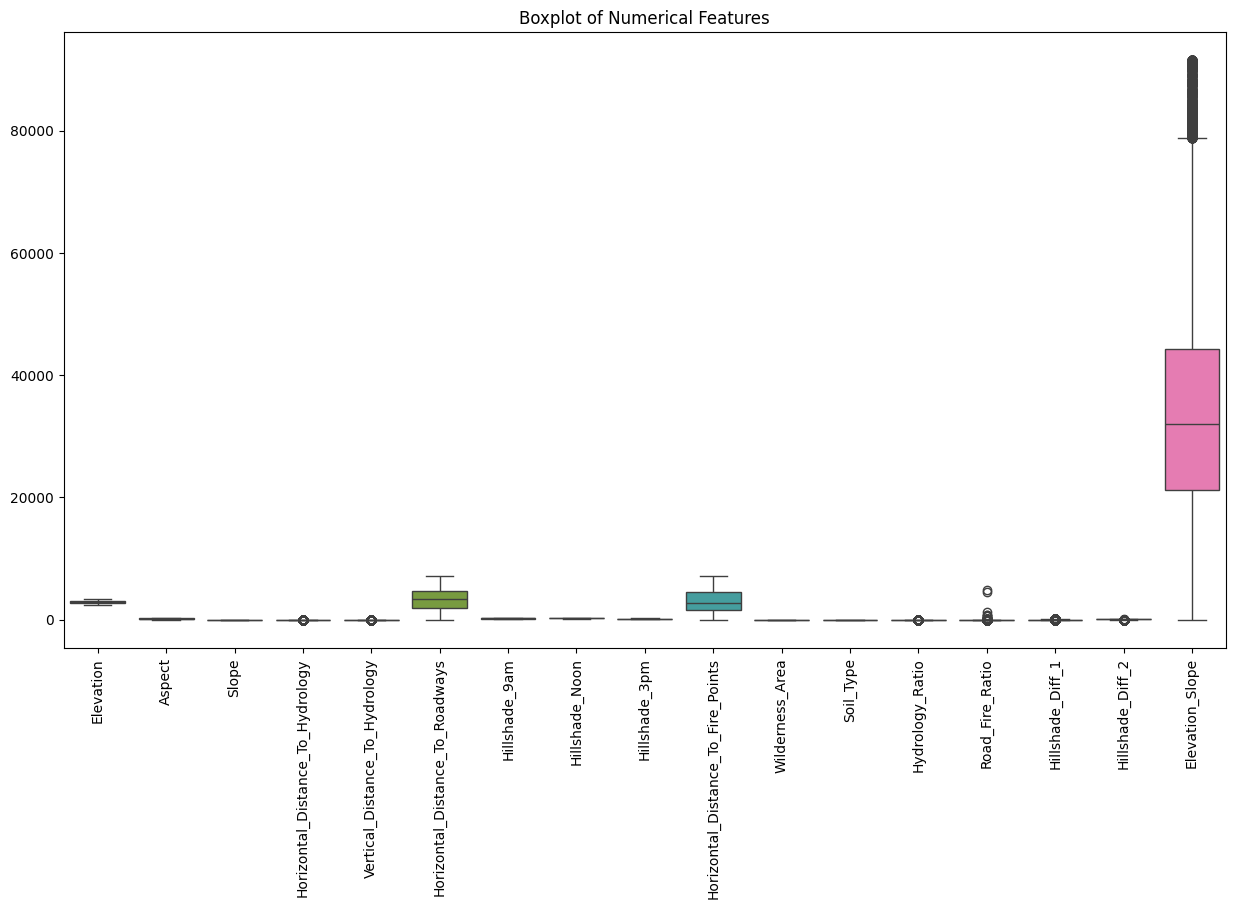

In [ ]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")
plt.show()

Target Variable Distribution (Class Imbalance)

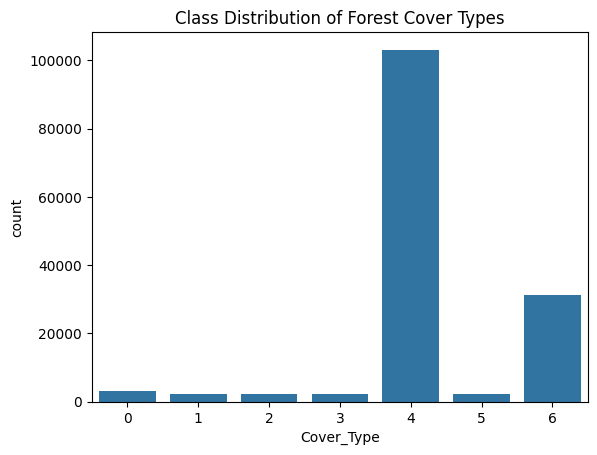

In [ ]:
sns.countplot(x='Cover_Type', data=df)
plt.title("Class Distribution of Forest Cover Types")
plt.show()

# 2. Bivariate Analysis (Feature vs Target)

Elevation vs Cover_Type

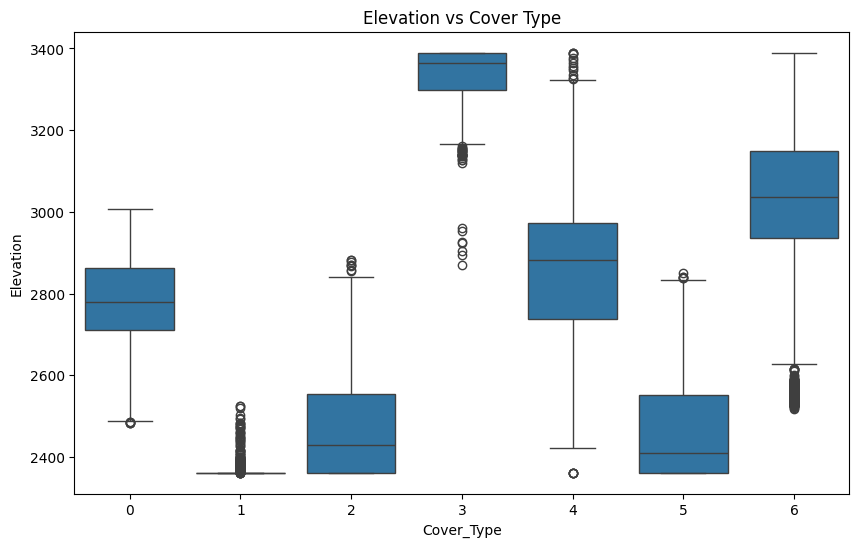

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Cover_Type', y='Elevation', data=df)
plt.title("Elevation vs Cover Type")
plt.show()

Distance Features vs Target

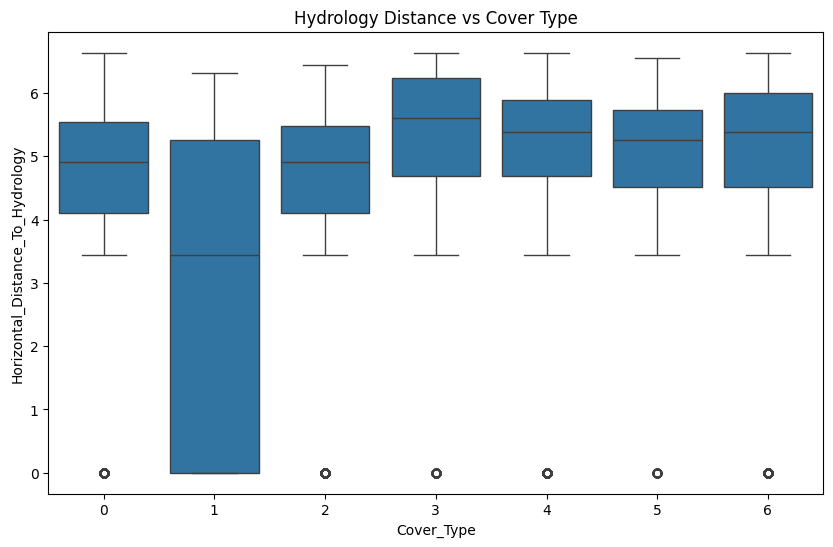

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Cover_Type', y='Horizontal_Distance_To_Hydrology', data=df)
plt.title("Hydrology Distance vs Cover Type")
plt.show()

Hillshade Analysis

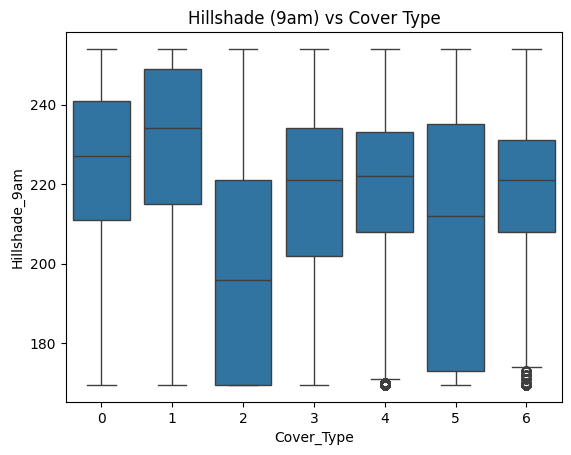

In [ ]:
sns.boxplot(x='Cover_Type', y='Hillshade_9am', data=df)
plt.title("Hillshade (9am) vs Cover Type")
plt.show()

# 3. Correlation Heatmap (Feature Relationships)

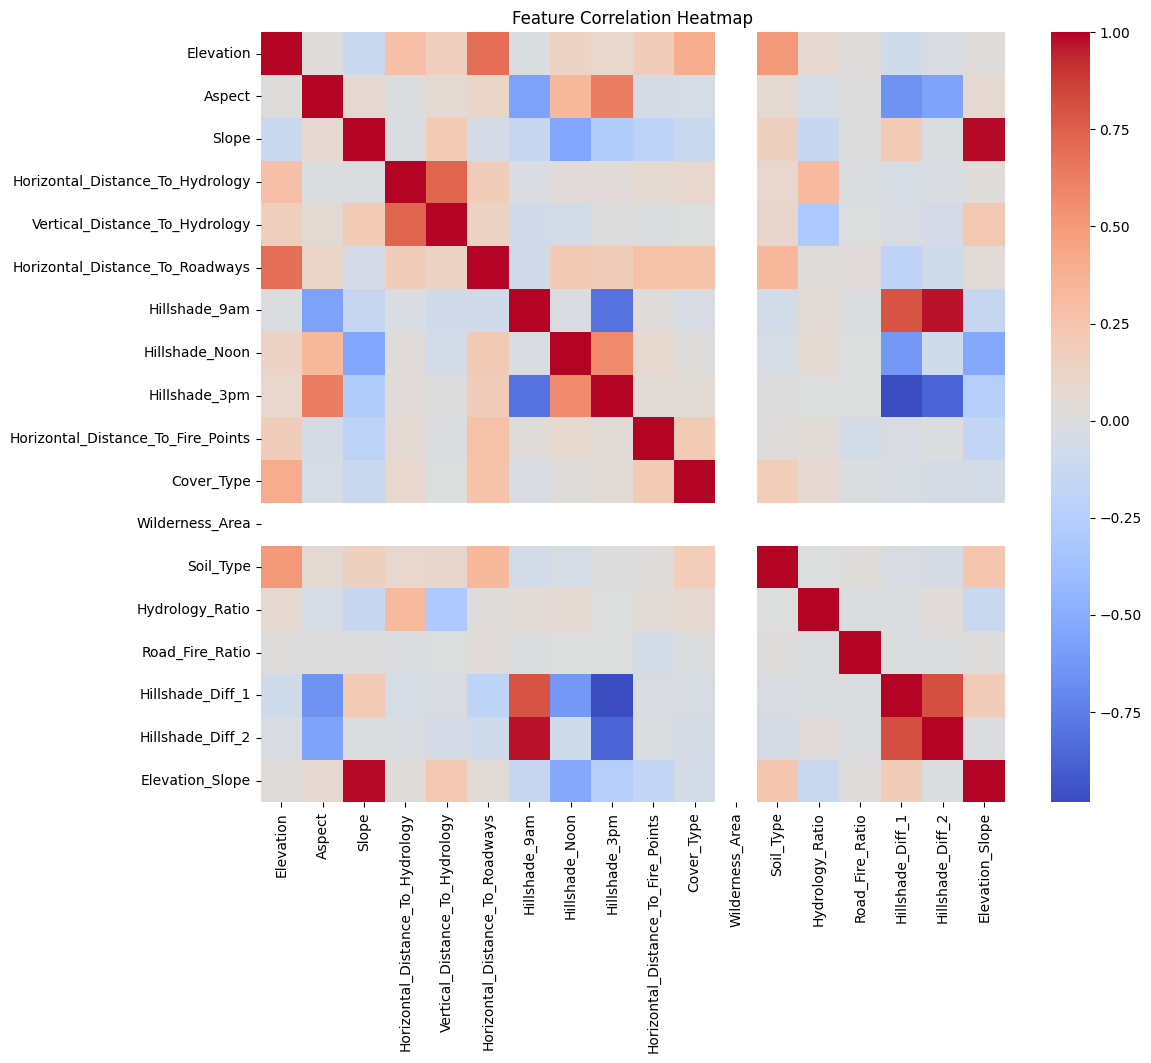

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

# 4. Feature Importance

Train a Quick Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Plot Feature Importance

In [ ]:
import pandas as pd

feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

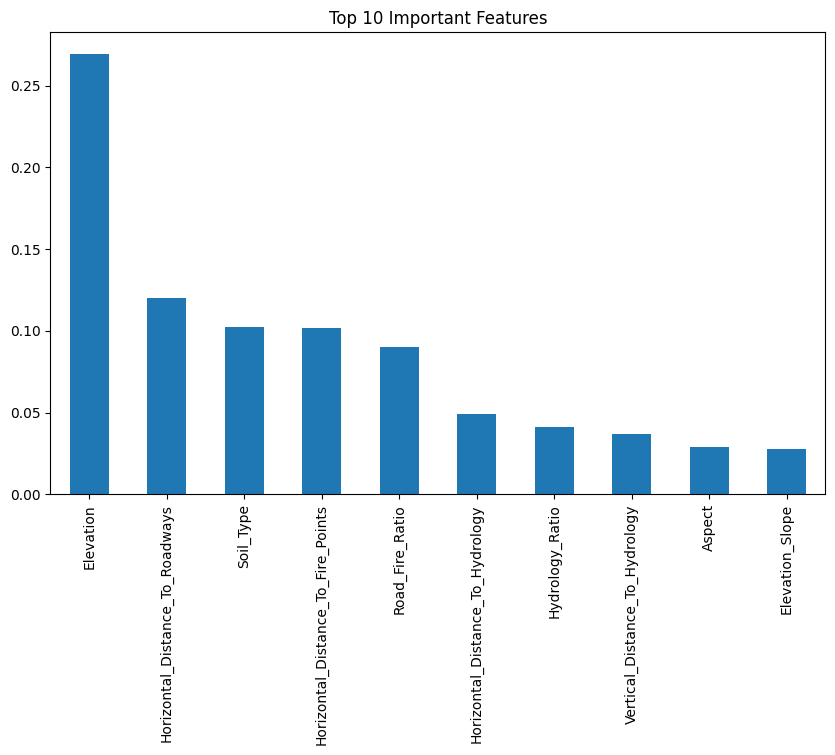

In [ ]:
plt.figure(figsize=(10,6))
feature_importances.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

# Step 6: Class Imbalance Handling

1. Check Class Imbalance (Before Handling)

In [ ]:
y.value_counts()

,count
Cover_Type,
4,103071
6,31110
0,3069
3,2160
5,2160
2,2160
1,2160


In [ ]:
y.value_counts(normalize=True) * 100

,proportion
Cover_Type,
4,70.649805
6,21.324285
0,2.103640
3,1.480568
5,1.480568
2,1.480568
1,1.480568


# 2. Split Data FIRST

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Apply SMOTE

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 4. Verify Balanced Data

In [ ]:
y_train_resampled.value_counts()

,count
Cover_Type,
4,82457
5,82457
1,82457
6,82457
3,82457
0,82457
2,82457


# 5. Alternative: RandomOverSampler

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Step 7: Feature Selection

Train on Balanced Data

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(random_state=42)

Extract Feature Importance

In [ ]:
import pandas as pd

feature_importances = pd.Series(rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

Visualize Top Features

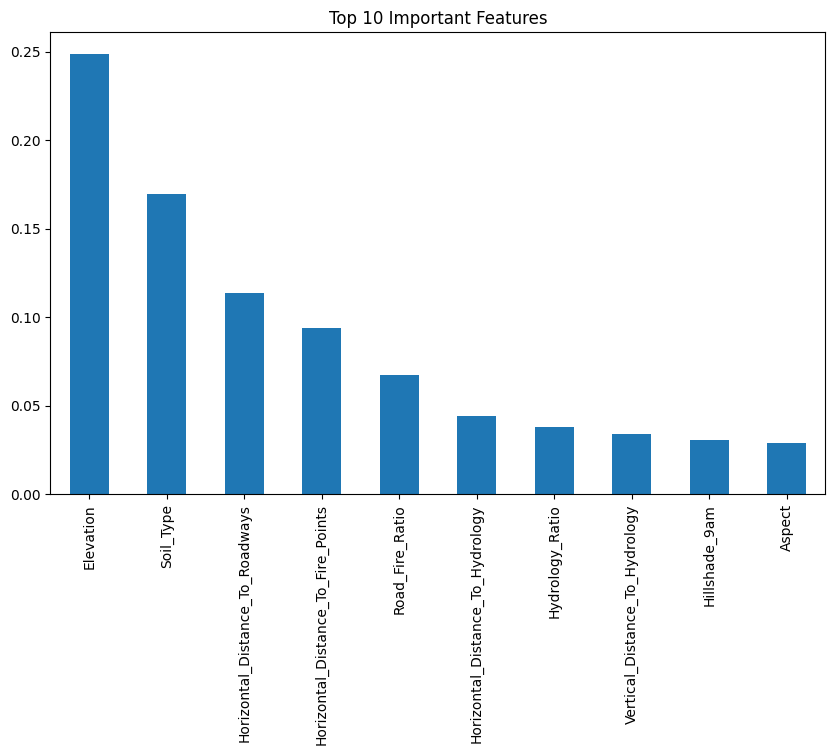

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
feature_importances.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

# 2. Identify Low Importance Features

In [ ]:
low_importance_features = feature_importances[feature_importances < 0.01].index
low_importance_features

Index(['Wilderness_Area'], dtype='object')

Drop Low Importance Features

In [ ]:
X = X.drop(columns=low_importance_features)

# 3. Low Variance Feature Removal

In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X)

In [ ]:
selected_cols = X.columns[selector.get_support()]
X = X[selected_cols]

# 4. Correlation-Based Feature Selection

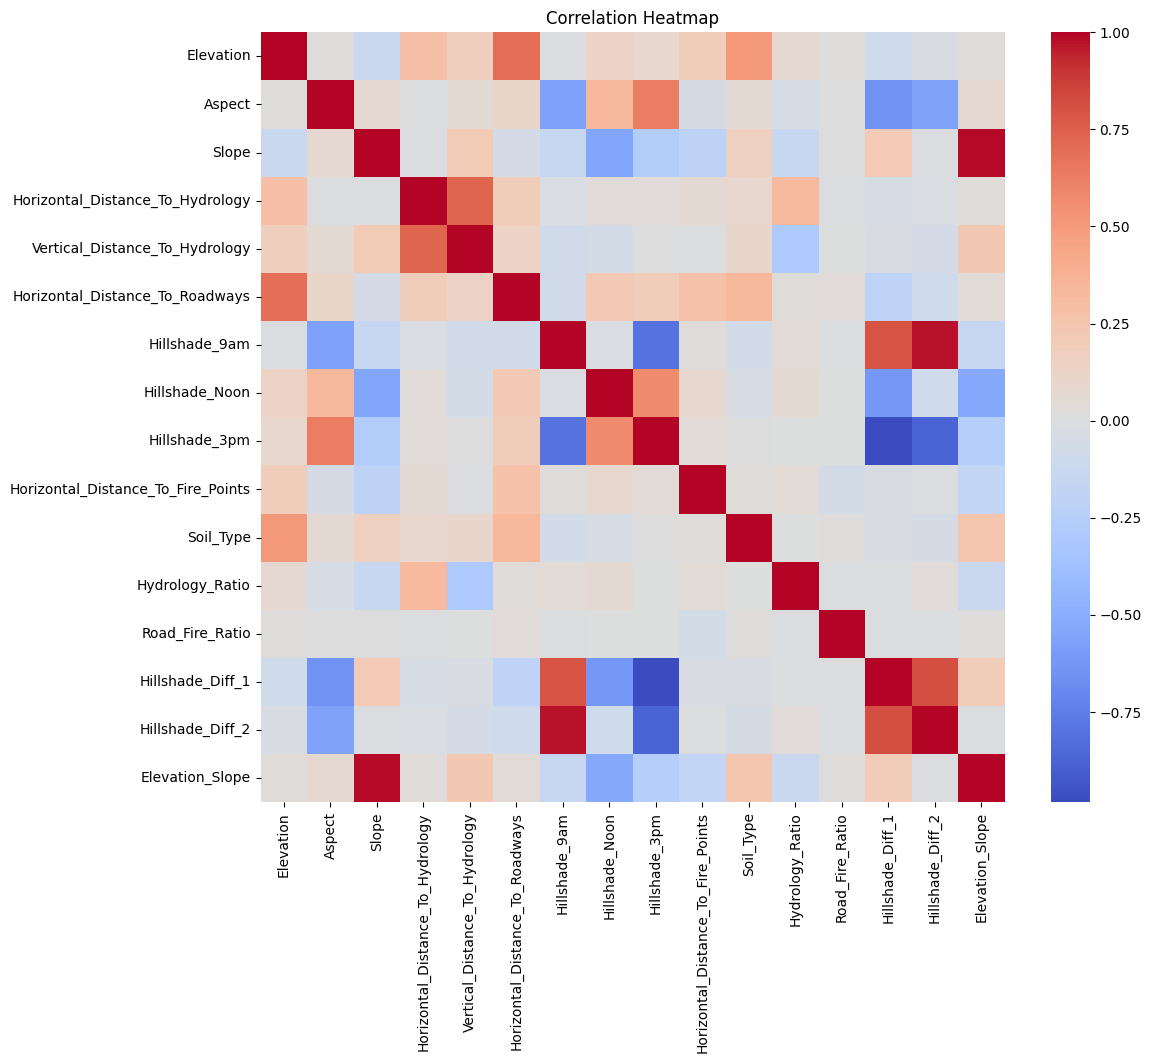

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,10))
corr_matrix = X.corr()

sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Drop Highly Correlated Features (> 0.9)

In [ ]:
import numpy as np

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

In [ ]:
X = X.drop(columns=to_drop)

# 5. Final Dataset Ready

In [ ]:
X.shape

(145890, 13)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Step 8: Model Building & Evaluation

1. Final Data Setup

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

2. Import Models

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

3. Train All Models

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=42)
}

4. Evaluation Function

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

5. Run All Models

In [ ]:
for name, model in models.items():
    evaluate_model(name, model, X_train_resampled, y_train_resampled, X_test, y_test)


Random Forest
----------------------------------------
Accuracy: 0.9553430666940845

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.94      0.88       614
           1       0.92      0.94      0.93       432
           2       0.79      0.83      0.81       432
           3       0.89      0.99      0.94       432
           4       0.98      0.97      0.97     20614
           5       0.82      0.84      0.83       432
           6       0.91      0.93      0.92      6222

    accuracy                           0.96     29178
   macro avg       0.88      0.92      0.90     29178
weighted avg       0.96      0.96      0.96     29178


Confusion Matrix:
 [[  577     0     4     0    25     7     1]
 [    0   407    12     0     0    13     0]
 [    3    18   359     0     6    46     0]
 [    0     0     0   428     0     0     4]
 [   83     0    26     5 19955    11   534]
 [    4    16    50     0     1   361     0]
 [ 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression
----------------------------------------
Accuracy: 0.4306669408458428

Classification Report:
               precision    recall  f1-score   support

           0       0.05      0.46      0.10       614
           1       0.31      0.72      0.44       432
           2       0.11      0.42      0.18       432
           3       0.19      0.84      0.31       432
           4       0.85      0.37      0.52     20614
           5       0.27      0.29      0.28       432
           6       0.37      0.58      0.45      6222

    accuracy                           0.43     29178
   macro avg       0.31      0.53      0.32     29178
weighted avg       0.69      0.43      0.48     29178


Confusion Matrix:
 [[ 281   10  103    9  139   29   43]
 [   2  313   48    0    4   65    0]
 [  39   99  183    1   28   79    3]
 [  14    0    5  364    0    3   46]
 [4299  438 1098  768 7684  147 6180]
 [  32  133  125    0   18  124    0]
 [ 549   12   88  785 1164    7 3617]]


6. Compare Accuracies

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

results

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'Random Forest': 0.9553430666940845,
 'Decision Tree': 0.9290561381863047,
 'Logistic Regression': 0.4306669408458428,
 'KNN': 0.8366920282404552,
 'XGBoost': 0.9091781479196654}

# 7. Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

In [ ]:
random_search.fit(X_train_resampled, y_train_resampled)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


# Restart Clean Pipeline

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cover_type (1).csv to cover_type (1).csv


In [ ]:
df = pd.read_csv('cover_type (1).csv')

In [ ]:
import pandas as pd
import numpy as np

# Feature Engineering (safe version)
df['Hydrology_Ratio'] = df['Horizontal_Distance_To_Hydrology'] / (abs(df['Vertical_Distance_To_Hydrology']) + 1)
df['Road_Fire_Ratio'] = df['Horizontal_Distance_To_Roadways'] / (df['Horizontal_Distance_To_Fire_Points'] + 1)
df['Hillshade_Diff_1'] = df['Hillshade_9am'] - df['Hillshade_Noon']
df['Hillshade_Diff_2'] = df['Hillshade_Noon'] - df['Hillshade_3pm']
df['Elevation_Slope'] = df['Elevation'] * df['Slope']

# Fix inf values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_804/4078724563.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Cover_Type'] = le.fit_transform(df['Cover_Type'])

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9587017616012063


In [ ]:
import joblib

joblib.dump(model, 'forest_model.pkl')
joblib.dump(le, 'target_encoder.pkl')

['target_encoder.pkl']

# 🔥 Final Model Code (Fast + Reliable)

In [ ]:
best_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)

# Step 9: Finalize and Save Best Model

1. Evaluate Your Final Model

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9629172664336144

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.92      0.91       614
           1       0.95      0.95      0.95       432
           2       0.84      0.88      0.86       432
           3       0.93      0.97      0.95       432
           4       0.98      0.98      0.98     20614
           5       0.85      0.86      0.85       432
           6       0.94      0.93      0.93      6222

    accuracy                           0.96     29178
   macro avg       0.91      0.93      0.92     29178
weighted avg       0.96      0.96      0.96     29178


Confusion Matrix:
 [[  563     0     3     0    40     7     1]
 [    0   409     9     0     0    14     0]
 [    4    10   380     0     1    37     0]
 [    1     0     0   419     1     0    11]
 [   44     0    15     5 20172     9   369]
 [    4    11    46     0     1   370     0]
 [   12     0     2    25   400     0  5783]]


2. Save Final Model

In [ ]:
import joblib

joblib.dump(best_model, 'forest_cover_model.pkl')

['forest_cover_model.pkl']

3. Save Target Encoder

In [ ]:
joblib.dump(le, 'target_encoder.pkl')

['target_encoder.pkl']

Save Feature Columns

In [ ]:
joblib.dump(X.columns, 'model_features.pkl')

['model_features.pkl']

5. Verify Files

In [ ]:
import os
os.listdir()

['.config',
 'model_features.pkl',
 'forest_cover_model.pkl',
 '.ipynb_checkpoints',
 'cover_type (1).csv',
 'target_encoder.pkl',
 'sample_data']

In [ ]:
from google.colab import files

files.download('forest_cover_model.pkl')
files.download('target_encoder.pkl')
files.download('model_features.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>